# 指数平滑法（PROC ESM）による救急外来受診数の予測


## エグゼクティブサマリー

ある中規模病院システムは、冬季の呼吸器サージに先立って看護師配置と病床キャパシティを計画するため、月次の救急外来（ED）受診数の 1 年先予測を必要とする。このノートブックは、合成の 4 年分の月次 ED 患者数（48 か月、2021 年 1 月 - 2024 年 12 月）を構築し、Winters 乗法季節モデルを **PROC ESM** で当てはめて、95% 予測区間付きの 12 か月予測を生成する。

当てはめたモデルは系列をよく捉える：標本内 **RMSE は約 320 受診**、**MAPE は 4.16%** であり、典型的な月次誤差は受診量の 5% 未満である。予測はおなじみの季節形状を 2025 年へ投影する――12 月〜2 月のピークは **月あたり約 7,300〜7,800 受診**、晩夏の谷は **約 5,800〜5,900** で、予測帯は地平が延びるにつれて広がる。これらの数値と、その背後にある平滑化ウェイトは、以下のプロシジャの出力データセットから直接読み取っている。


## データソース

| データセット | 行数 | 粒度 | 主な変数 | 説明 |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | 暦月ごとに 1 行、2021 年 1 月 - 2024 年 12 月 | `month`（月次 SAS 日付）、`ed_visits`（整数の月次 ED 受診数） | 中規模病院システムの合成月次救急外来受診数。上昇トレンド（年約 3%）、冬季呼吸器シーズン（12 月〜2 月）にピークを迎え晩夏に落ち込む乗法季節サイクル、加えて対数正規ノイズで生成され、季節振幅は上昇する水準に比例してスケールする。 |


# PROC ESM による救急外来受診数の予測

キャパシティ計画者は、看護師のシフトを組み、フレックス病床を確保し、冬季サージの前に呼吸器用品を準備できるよう、毎月何件の ED 受診を見込めばよいかを知る必要がある。ED 受診量は教科書的な季節時系列である：年を追ってゆっくり成長し、12 月〜2 月の呼吸器シーズンにピークを迎え、晩夏に引く。そして季節の振れ幅はベースライン受診量が増えるにつれて大きくなる。その乗法季節構造こそ、**PROC ESM** の Winters 乗法法が捉えるよう設計されているものである。

このノートブックでは：

1. トレンド、乗法季節性、ノイズを備えた現実的な 4 年分の月次 ED 患者数を生成する。
2. 系列を可視化して、その乗法季節構造を確認する。
3. Winters 乗法モデルを PROC ESM で当てはめ、出力データセットから平滑化ウェイトと適合統計量を読む。
4. 95% 予測区間付きの 12 か月先予測を生成し、運用上の含意を解釈する。


## ステップ 1 - 合成月次 ED 患者数の生成

2021 年 1 月から 2024 年 12 月までの 48 個の月次観測を構築する。各月の期待受診量は、年約 3% 成長するベースライン水準に季節指数（真冬に最高、晩夏に最低）を掛け、対数正規ノイズで撹乱して、ランダム変動が水準に比例してスケールするようにする。`intnx` は月に整列した日付を 1 行につき 1 期間進め、`streaminit` は抽出を再現可能にする。


In [1]:
データ ed_census;
    呼出 streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    配列 seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    書式 month yymmn6.;
    繰返 i = 1 から 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        出力;
    終了;
    保持 month ed_visits;
実行;

処理 印刷 データ=ed_census(obs=14) noobs 見出;
    見出 month = '月' ed_visits = 'ER受診数';
    表題 '合成 ER 受診数ボリュームの最初の 14 か月';
実行;


                                                合成 ER 受診数ボリュームの最初の 14 か月                                                

     月        ER受診数
202101         7103
202102         6835
202103         6668
202104         5611
202105         5816
202106         5383
202107         5586
202108         5283
202109         5161
202110         6109
202111         6451
202112         6730
202201         6847
202202         7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


最初の数か月は設計を裏付ける：受診量は 2021 年 1 月のピークで 7,100 付近に始まり、春から夏にかけて 8 月〜9 月の谷まで落ち、その後次の冬へ登り返す。2022 年 1 月までにピークは約 6,800〜7,200 へと上がり、季節サイクルに重なった年約 3% の成長を反映している。


## ステップ 2 - 系列の可視化

モデル化の前に、期待する構造を確認するため生の系列をプロットする：緩やかな上昇トレンドと、毎冬繰り返すピークで、その振幅は時間とともに広がる。広がる季節の振れは *乗法* 季節過程の特徴であり、どの ESM モデルを選ぶべきかを教えてくれる。


                                                合成 ER 受診数ボリュームの最初の 14 か月                                                




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


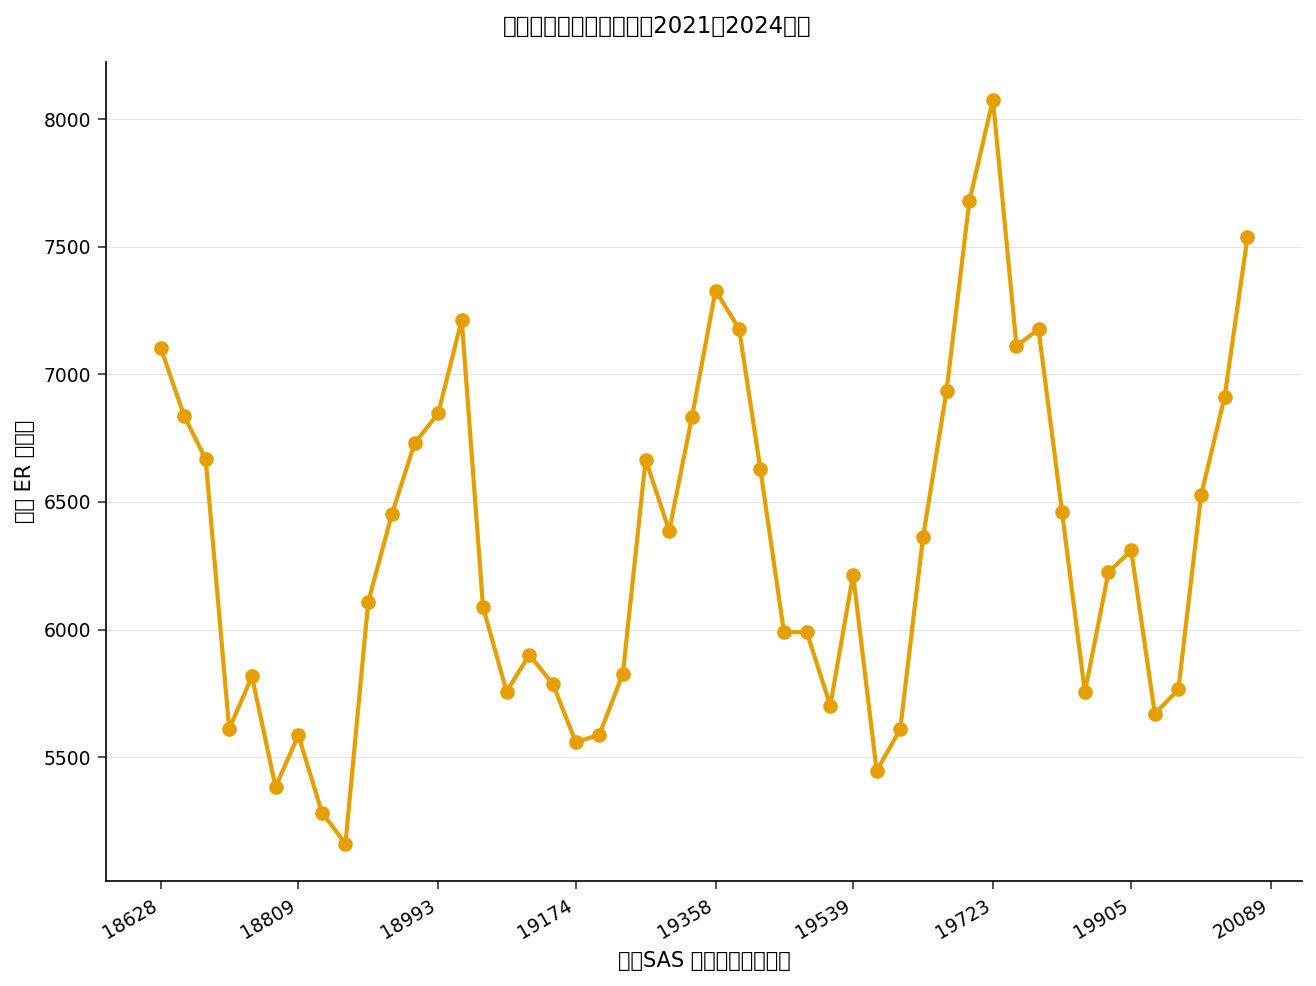

In [2]:
処理 SGPLOT データ=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS 見出='月（SAS 月インデックス）';
    YAXIS 見出='月次 ER 受診数' grid;
    表題 '救急外来の月次受診数（2021〜2024年）';
実行;


プロットは 4 つのきれいな年次サイクルを示す。各冬のピークは前回より少しずつ高く、2021 年の約 7,100 から 2024 年ピークの約 8,100 まで登る一方、夏の谷はより控えめに上昇する――季節の振れは水準とともに大きくなる。その広がる振幅は乗法季節性の証であり、次のステップで `MODEL=WINTERS`（Winters 乗法）を正当化する。


## ステップ 3 - Winters 乗法モデルの当てはめ

48 か月の全履歴に Winters 乗法季節平滑化を当てはめる。`ID` ステートメントは `month` を `MONTH` 間隔の時間インデックスとして宣言し、`FORECAST` ステートメントは `MODEL=WINTERS` を `LEAD=12` で要求して 1 年先を投影する。3 つの出力データセットを取得する：

- `OUT=` - 履歴系列に予測を付加したもの（`ed_visits` 列 1 本）で、時間 ID は予測地平にわたって延長される――プロットに理想的。
- `OUTFOR=` - 期間ごとの予測成分：点予測（`PREDICT`）と下側／上側の予測限界。
- `OUTSUM=` - モデルの適合統計量（RMSE、MAE、MAPE、AIC）と平滑化ウェイトを、1 行の要約にまとめたもの。

`ALPHA=0.05` は 95% 予測限界を与え、キャパシティ計画のリスク余裕に適する。`PRINT=(STATISTICS)` は適合統計量と平滑化ウェイトをリスティングへ出力する。


In [3]:
処理 esm データ=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        印刷=(statistics);
    id month interval=month;
    forecast ed_visits / 模型=winters ALPHA=0.05;
実行;

処理 印刷 データ=esm_summary noobs 見出;
    見出 rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='水準（α）' beta='トレンド（β）' gamma='季節（γ）';
    変数 rmse mae mape ALPHA beta gamma;
    表題 'Winters 法の当てはめ統計量と平滑化重み';
実行;


                                                合成 ER 受診数ボリュームの最初の 14 か月                                                


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                                Winters 法の当てはめ統計量と平滑化重み                                                 

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


`OUTSUM=` の行と印字された統計量は一致する：Winters 乗法フィットは標本内で **RMSE 320.4 受診**、**MAE 264.4**、**MAPE 4.16%** を達成する――典型的な月次誤差は受診量の 5% を十分下回り、配置計画には快適に正確である。平滑化ウェイトは **alpha = 0.30**（水準）、**beta = 0.10**（トレンド）、**gamma = 0.10**（季節）である。中程度の水準ウェイトはベースラインが患者人口の成長とともに上方へ漂うことを許し、小さいトレンドと季節ウェイトは、成長率と冬季サージの形状が年ごとに安定しており、月ごとに過剰反応すべきでないことを反映している。

> 注：これらは *標本内* の適合統計量で、推定標本にわたって計算されたものであり、標本外のホールドアウトではない。モデルが当てはめた履歴をどれだけ密に追うかを定量化する。


## ステップ 4 - 12 か月予測の組み立てと表化

`OUTFOR=` データセットは各期間の点予測と予測限界を保持し、`OUT=` データセットは時間 ID を予測地平にわたってきれいに延長して持つ。この 2 つを観測順で整列させて予測日を予測限界に付与し、予測 12 か月分だけを残す。これらが、配置委員会が実際に動く数値である。


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
データ out_idx;
    設定 ed_with_forecast;
    row = _n_;
    改名 month = fdate ed_visits = series_value;
実行;

データ for_idx;
    設定 esm_forecast;
    row = _n_;
    改名 ed_visits = observed;
    保持 row observed predict LOWER UPPER;
実行;

データ forecast_path;
    結合 out_idx for_idx;
    基準 row;
    書式 fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
実行;

データ forecast_horizon;
    設定 forecast_path;
    条件 observed = .;   /* forecast months only (no observed value) */
    保持 fdate predict LOWER UPPER;
実行;

処理 印刷 データ=forecast_horizon noobs 見出;
    見出 fdate   = '月'
          predict = '予測受診数'
          LOWER   = '95% 下限'
          UPPER   = '95% 上限';
    表題 '12 か月先 ER 受診数予測と 95% 予測限界';
実行;


                                               12 か月先 ER 受診数予測と 95% 予測限界                                                

     月            予測受診数      95% 下限      95% 上限
202501            7,822       7,194       8,450
202502            7,539       6,651       8,427
202503            7,292       6,204       8,380
202504            6,263       5,007       7,519
202505            6,397       4,992       7,801
202506            6,039       4,501       7,578
202507            6,236       4,574       7,897
202508            5,867       4,091       7,644
202509            5,802       3,918       7,686
202510            6,804       4,818       8,790
202511            7,173       5,090       9,256
202512            7,567       5,391       9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


予測は季節の署名を 2025 年へと運ぶ。モデルは 2025 年 1 月のピークを約 **7,822 受診**（95% 区間 7,194〜8,450）と投影し、春にかけて緩み、9 月の晩夏の谷 **約 5,802**（区間 3,918〜7,686）で底を打ち、その後 12 月ピークの約 **7,567**（区間 5,391〜9,742）へと立て直す。予測帯は地平とともに着実に広がる――翌月の区間は約 ±630 受診に及ぶ一方、翌年 12 月の区間は ±2,000 超に及ぶ――近い将来の計画が年末のものよりはるかに確かであることを直接思い出させる。


## ステップ 5 - 履歴と予測のプロット

最後に、観測履歴に予測を重ね、計画者が投影された冬季ピークと、地平が延びるにつれて広がる不確実性帯を見られるようにする。整列した `forecast_path` 系列を **観測** 履歴（実線）と **12 か月予測**（破線）に分割して受け渡しを明確にし、その下に 95% 予測帯を描く。x 軸は月次 SAS 日付インデックスで、2021 年 1 月から 2025 年 12 月まで左から右へ走る。


                                               12 か月先 ER 受診数予測と 95% 予測限界                                                




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


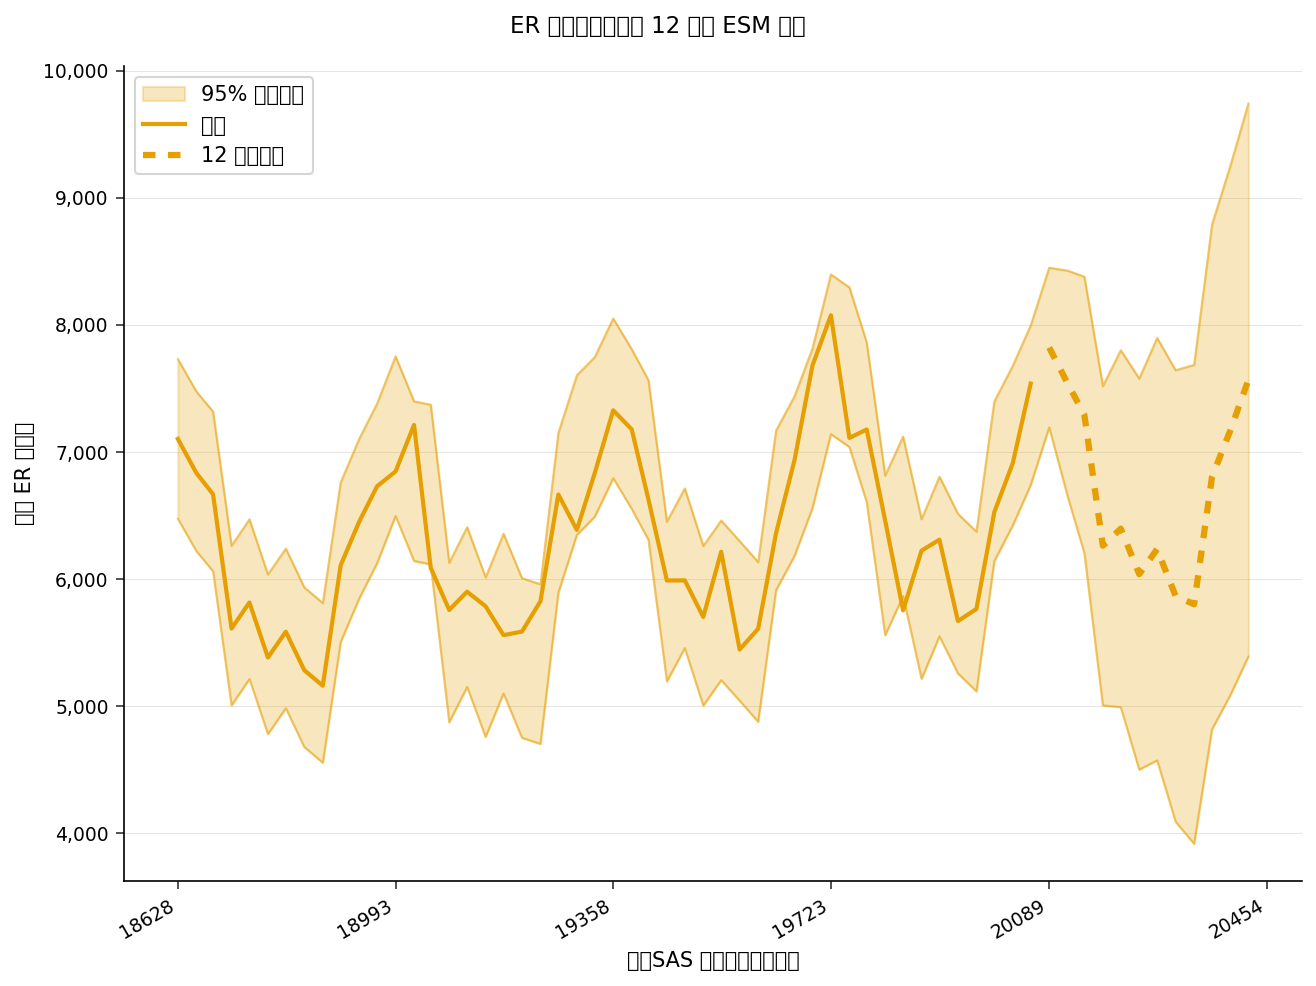

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
データ forecast_plot;
    設定 forecast_path;
    もし observed = . なら fc_only = predict;   /* future months only */
    他 fc_only = .;
実行;

処理 SGPLOT データ=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='95% 予測区間' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='実績';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='12 か月予測';
    XAXIS 見出='月（SAS 月インデックス）';
    YAXIS 見出='月次 ER 受診数' grid;
    表題 'ER 受診数：実績と 12 か月 ESM 予測';
実行;


## 結果の解釈

Winters 乗法モデルは ED 受診量を、ゆっくり上昇する **水準**、ほぼ平坦な **トレンド**、安定した **季節** パターンへと分解する。`OUTSUM=` から読み取った平滑化ウェイトが経緯を物語る：中程度の水準ウェイト（alpha = 0.30）はベースラインが患者人口の成長とともに上方へ漂うことを許し、小さいトレンドと季節ウェイト（beta = gamma = 0.10）は、成長率と冬季サージの形状が年ごとに極めて安定しており、月ごとに過剰反応すべきでないことを反映している。

**適合統計量** はモデルが履歴をよく追うことを裏付ける：RMSE 約 320 受診、MAPE 4.16% は、典型的な月次誤差が受診量の 5% 未満であることを意味する。運用面では、**予測表と帯プロット** が、ED が備えるべき 12 月〜2 月のピーク――冬季の月々でおよそ 7,300〜7,800 受診――を定量化し、95% 予測限界が慎重なキャパシティ範囲を定める：中核配置は点予測に合わせ、フレックスカバレッジとサージ病床は上限に向けて事前手配する。区間は地平とともに広がるため、翌月の計画は翌年 12 月のものよりはるかに確かであり、新しい実績が届くたびに更新すべきである。

**発展：** `MODEL=ADDWINTERS`（加法季節性）を乗法フィットと比較して乗法の選択を確認する。`TRANSFORM=LOG` を適用して正値性を強制し分散を安定化する。あるいは `BY` ステートメントを加えて、単一の PROC ESM 呼び出しで複数の病院サイトを予測する。
